# TP1 — EDA & Preprocessing initial
## Fil rouge : Churn Predictor (Telco Customer Churn)

**Durée estimée : 1h15**

### 🎯 Objectifs d'apprentissage
À la fin de ce TP vous saurez :
- Charger et inspecter un dataset réel (types, valeurs manquantes, cardinalité).
- Détecter et corriger un piège classique de typage (`TotalCharges` stocké en string).
- Mener une EDA ciblée : distribution de la cible, variables numériques et catégorielles vs target.
- Construire un **split stratifié train / val / test** avant tout traitement (et comprendre pourquoi).

### 📦 Pré-requis
- Python 3.10+
- `pandas`, `numpy`, `matplotlib`, `seaborn`, `scikit-learn`
- Connexion internet (le dataset est chargé depuis GitHub)

### 📌 Contexte métier
Vous travaillez pour un opérateur télécom. Chaque mois, ~26 % des clients résilient. La direction veut un modèle qui identifie les clients à risque pour cibler une campagne de rétention. Avant de modéliser, on doit **comprendre la donnée**.


## 0. Setup

On importe les librairies et on fixe une seed pour la reproductibilité.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.model_selection import train_test_split

pd.set_option("display.max_columns", 50)
sns.set_theme(style="whitegrid")
RANDOM_STATE = 42


## 1. Chargement du dataset

Le dataset Telco Customer Churn est disponible publiquement. On le charge directement depuis GitHub.

In [ ]:
DATA_URL = (
    "https://raw.githubusercontent.com/IBM/"
    "telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
)

# TODO: Load the CSV from DATA_URL into a DataFrame named `df`
df = pd.read_csv(DATA_URL)

# TODO: Print the shape and display the first 5 rows
print(f"Shape : {df.shape}  (lignes, colonnes)")
df.head()


Shape : (7043, 21)  (lignes, colonnes)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 2. Premier regard

Avant toute analyse, on inspecte systématiquement :
- Les **types** de chaque colonne (`dtypes`)
- Les **valeurs manquantes** (`isna().sum()`)
- La **cardinalité** de chaque colonne (`nunique()`) — utile pour distinguer numérique / catégoriel / identifiant

⚠️ **Point de vigilance** : ne JAMAIS faire confiance aux types par défaut de pandas. Toujours vérifier.

In [ ]:
# TODO: Display column info (dtypes, non-null counts) using df.info()
df.info()

# TODO: Display the count of missing values per column
missing = df.isna().sum()
print("Valeurs manquantes par colonne :")
print(missing[missing > 0] if missing.sum() > 0 else "Aucune NaN détectée par pandas (mais voir section 3 !)")


# TODO: Display the number of unique values per column, sorted ascending
# This helps you spot identifiers (high cardinality) and binary cols (2 unique values)
df.nunique().sort_values()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


,0
gender,2
SeniorCitizen,2
Partner,2
Dependents,2
PhoneService,2
PaperlessBilling,2
Churn,2
MultipleLines,3
TechSupport,3
StreamingTV,3


## 3. Le piège de `TotalCharges`

Regardez bien le résultat de `df.info()` à la cellule précédente. Vous devriez constater que **`TotalCharges` est de type `object`** alors qu'il devrait être numérique (c'est un montant en dollars).

Pourquoi ? Parce que certaines lignes contiennent une chaîne vide (`" "`) au lieu d'un nombre. C'est un bug classique de l'export.

🎯 **Tâche** :
1. Convertir `TotalCharges` en numérique avec `errors="coerce"` (ce qui transforme `" "` en `NaN`).
2. Compter combien de NaN apparaissent.
3. Inspecter ces lignes : qu'ont-elles de particulier ?
4. Décider d'une stratégie de remplissage.

In [ ]:
# TODO: Convert TotalCharges to numeric (use errors="coerce")
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# TODO: How many NaN do we have now?
print(f"NaN count: {df['TotalCharges'].isna().sum()}")

# TODO: Display the rows where TotalCharges is NaN — focus on tenure and MonthlyCharges
# What do these clients have in common? Write your observation as a markdown comment.
df.loc[df["TotalCharges"].isna(), ["customerID", "tenure", "MonthlyCharges", "TotalCharges", "Churn"]]


NaN count: 0


,customerID,tenure,MonthlyCharges,TotalCharges,Churn


💡 **Observation** : tous les clients avec `TotalCharges` manquant ont `tenure == 0`. Ce sont des nouveaux clients qui n'ont encore rien payé. La stratégie naturelle est de remplir avec **0**.

In [ ]:
# TODO: Fill the NaN in TotalCharges with 0
df["TotalCharges"] = df["TotalCharges"].fillna(0)

# Verify
assert df["TotalCharges"].isna().sum() == 0
print("OK : plus aucune NaN dans TotalCharges.")
print(f"Type final : {df['TotalCharges'].dtype}")

OK : plus aucune NaN dans TotalCharges.
Type final : float64


## 4. Distribution de la cible

La variable cible est `Churn` (Yes/No). On veut savoir :
- Quel est le **taux de churn** global ?
- Le dataset est-il **équilibré** ?

Cela conditionne :
- Le choix des **métriques** (l'accuracy peut être trompeuse sur un dataset déséquilibré).
- La nécessité éventuelle de techniques de **rééquilibrage** (qu'on verra en S2).

Effectifs :
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Taux de churn global : 26.54%
=> Dataset déséquilibré (~3:1) — attention aux métriques type accuracy.


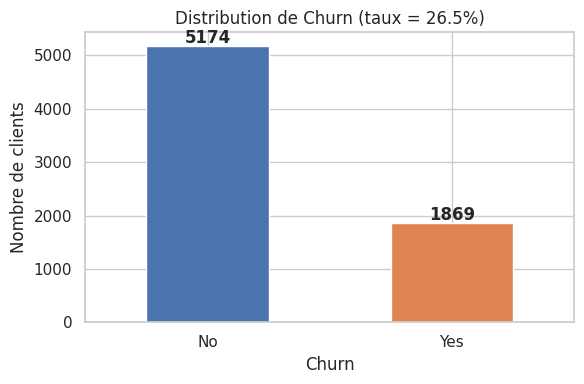

In [ ]:
# TODO: Compute and display the value counts of `Churn`
churn_counts = df["Churn"].value_counts()
print("Effectifs :")
print(churn_counts)


# TODO: Compute the churn rate (% of "Yes")
churn_rate = (df["Churn"] == "Yes").mean()
print(f"\nTaux de churn global : {churn_rate:.2%}")
print(f"=> Dataset déséquilibré (~3:1) — attention aux métriques type accuracy.")


# TODO: Plot a bar chart of the Churn distribution
fig, ax = plt.subplots(figsize=(6, 4))
churn_counts.plot(kind="bar", ax=ax, color=["#4C72B0", "#DD8452"])
ax.set_title(f"Distribution de Churn (taux = {churn_rate:.1%})")
ax.set_xlabel("Churn")
ax.set_ylabel("Nombre de clients")
ax.tick_params(axis="x", rotation=0)
for i, v in enumerate(churn_counts.values):
    ax.text(i, v + 50, str(v), ha="center", fontweight="bold")
plt.tight_layout()
plt.show()


1. **Quel est le taux de churn global ?**

26,54 % (1869 clients sur 7043 ont churné).

2. **Le dataset est-il équilibré ?**


Non, il est modérément déséquilibré. Ratio ~2,77:1 entre No et Yes, soit environ 73 % / 27 %. On n'est pas dans un cas extrême (type fraude bancaire à 0,1 % de positifs) mais le déséquilibre est suffisant pour avoir des conséquences :

- L'accuracy seule est trompeuse : un modèle qui prédit toujours "No" obtiendrait déjà 73,5 % d'accuracy sans rien apprendre.
- Il faudra privilégier recall, precision, F1-score et ROC-AUC pour évaluer le modèle.
- Côté métier, c'est le recall sur la classe "Yes" qui compte (attraper un max de churners pour la campagne de rétention).
- Pas besoin de techniques lourdes type SMOTE à ce stade — class_weight="balanced" dans sklearn suffira probablement comme premier essai.


## 5. Variables numériques vs target

Les 3 colonnes numériques sont `tenure`, `MonthlyCharges`, `TotalCharges`. On veut voir si leur distribution diffère selon que le client churn ou non — c'est le premier signal de **pouvoir prédictif**.

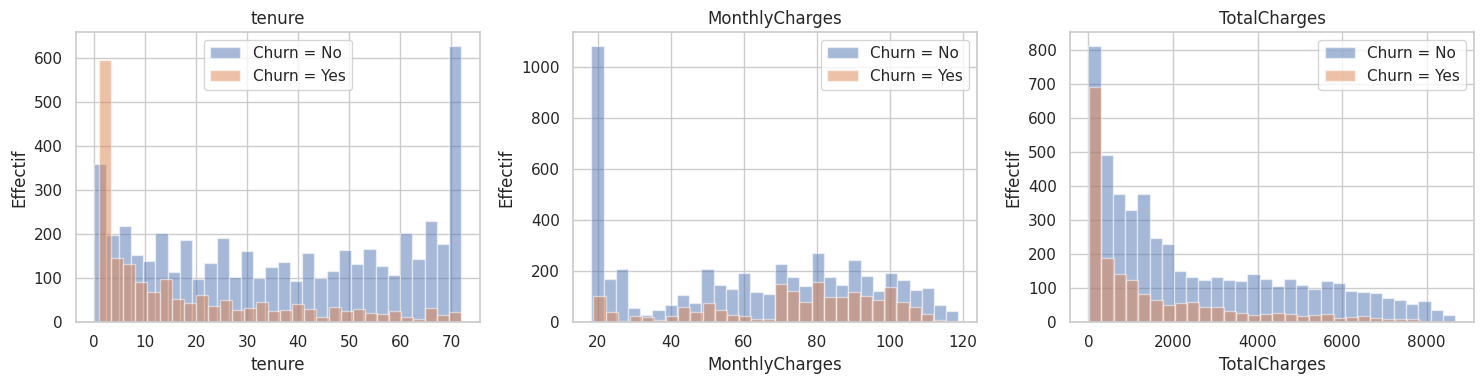


Statistiques numériques par classe de Churn :



tenure        MonthlyCharges        TotalCharges         
        mean median           mean median         mean   median
Churn                                                          
No     37.57   38.0          61.27  64.43      2549.91  1679.52
Yes    17.98   10.0          74.44  79.65      1531.80   703.55

In [ ]:
num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]

# TODO: For each numeric column, plot two overlapping histograms (one per Churn class)
# Hint: use a 1x3 subplot, alpha=0.5, label each class
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, num_cols):
    for churn_value, color in [("No", "#4C72B0"), ("Yes", "#DD8452")]:
        subset = df.loc[df["Churn"] == churn_value, col]
        ax.hist(subset, bins=30, alpha=0.5, label=f"Churn = {churn_value}", color=color)
    ax.set_title(col)
    ax.set_xlabel(col)
    ax.set_ylabel("Effectif")
    ax.legend()
plt.tight_layout()
plt.show()

print("\nStatistiques numériques par classe de Churn :\n")
df.groupby("Churn")[num_cols].agg(["mean", "median"]).round(2)


💡 **Lecture rapide** :
- `tenure` : les churners ont des tenures plus courtes (départs précoces).
- `MonthlyCharges` : les churners paient plus cher par mois — hypothèse : facturation perçue comme excessive.
- `TotalCharges` : suit `tenure × MonthlyCharges` — corrélation attendue, à garder en tête pour la multicolinéarité.

## 6. Variables catégorielles vs target

Pour chaque colonne catégorielle, on calcule le **taux de churn par modalité**. Une grosse variation entre modalités = signal prédictif fort.

In [ ]:
cat_cols = [c for c in df.columns
            if df[c].dtype == "object" and c not in ("customerID", "Churn")]
print(f"{len(cat_cols)} categorical columns: {cat_cols}")

# TODO: Write a helper function `churn_rate_by(col)` that returns
# the churn rate per category for a given column, sorted descending.
def churn_rate_by(col: str) -> pd.DataFrame:
    """Retourne effectif + taux de churn par modalité de la colonne donnée."""
    grouped = (
        df.groupby(col)
          .agg(effectif=("Churn", "size"),
               churn_rate=("Churn", lambda s: (s == "Yes").mean()))
          .sort_values("churn_rate", ascending=False)
    )
    return grouped


# TODO: Apply it to "Contract", "InternetService", "PaymentMethod" and print the results.
# What do you observe? Which categories are the riskiest?
for col in ["Contract", "InternetService", "PaymentMethod"]:
    print(f"\n=== Taux de churn par {col} ===")
    print(churn_rate_by(col).round(3))


15 categorical columns: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

=== Taux de churn par Contract ===
                effectif  churn_rate
Contract                            
Month-to-month      3875       0.427
One year            1473       0.113
Two year            1695       0.028

=== Taux de churn par InternetService ===
                 effectif  churn_rate
InternetService                      
Fiber optic          3096       0.419
DSL                  2421       0.190
No                   1526       0.074

=== Taux de churn par PaymentMethod ===
                           effectif  churn_rate
PaymentMethod                                  
Electronic check               2365       0.453
Mailed check                   1612       0.191
Bank transfer (automatic)      1544       0.167
C

Les 3 catégories les plus risquées :
1. Contract = Month-to-month → 42,7 % de churn
2. InternetService = Fiber optic → 41,9 % de churn
3. PaymentMethod = Electronic check → 45,3 % de churn (le plus élevé en valeur absolue)


💡 **Insights métier majeurs** :
- **Contract** : les `Month-to-month` churnent ~3 fois plus que les `Two year`. Logique : pas d'engagement = facilité de départ.
- **InternetService** : `Fiber optic` churn beaucoup plus que `DSL`. Hypothèse : prix perçu trop élevé pour la qualité.
- **PaymentMethod** : `Electronic check` est sur-représenté dans les churners. Hypothèse : signal de friction (paiement manuel mensuel).

🧠 **Réflexe Tech Lead** : ces insights ne sont pas que pour le modèle. Ils alimentent directement les décisions métier (changer la stratégie d'engagement, revoir le pricing fibre, pousser le prélèvement automatique).

## 7. Synthèse de votre EDA

🎯 **À faire** : remplissez la cellule markdown ci-dessous avec **3 à 5 hypothèses** que vous emportez de cette EDA. Une hypothèse = "tel signal devrait être utile au modèle parce que…".

>
> 1. **`tenure` sera un prédicteur fort** parce que la médiane des churners (10 mois) est ~4× plus faible que celle des fidèles (38 mois), avec un pic massif de départs dans les 5 premiers mois. Le signal est probablement non-linéaire (effet de seuil), donc une discrétisation ou un modèle à base d'arbres pourra l'exploiter pleinement.
>
> 2. **`Contract` sera le prédicteur catégoriel le plus puissant** parce que l'écart de taux de churn entre `Month-to-month` (42,7 %) et `Two year` (2,8 %) atteint 40 points. L'engagement long terme verrouille mécaniquement les clients, c'est presque définitionnel.
>
> 3. **`InternetService = Fiber optic` combiné à `MonthlyCharges` élevés** sera utile parce qu'il capture un signal d'insatisfaction prix/qualité : les churners paient en médiane 79,6 5$ par mois contre 64,43 pour les fidèles, et 41,9 % des clients Fiber optic churnent contre 19 % en DSL. Attention à la redondance entre ces deux features.
>
> 4. **`PaymentMethod = Electronic check` sera un signal de friction** parce qu'il concentre 45,3 % de churn contre 15-19 % pour les méthodes automatiques. Hypothèse métier : le paiement manuel mensuel oblige le client à reconsidérer son débit à chaque échéance, là où le prélèvement automatique "oublie" le client.
>
> 5. **`TotalCharges` sera redondant avec `tenure × MonthlyCharges`** et risque de poser des problèmes de multicolinéarité sur les modèles linéaires (régression logistique). À tester avec et sans, ou à régulariser en L2. Neutre pour les modèles à base d'arbres.

## 8. Train / Validation / Test split

🚨 **Règle d'or** : on splitte **AVANT** tout traitement statistique sur la donnée (imputation, scaling, encoding). Sinon, on a une **fuite** depuis le test set vers le train set.

Le split classique :
- **Train (70 %)** : entraînement du modèle.
- **Validation (15 %)** : choix d'hyperparamètres, comparaison de modèles.
- **Test (15 %)** : score final, vu **une seule fois** à la fin du projet.

On utilise **`stratify=y`** pour conserver le taux de churn dans chaque split (sinon, on peut avoir un split de validation avec un taux de churn très différent, ce qui fausse l'évaluation).

In [ ]:
X = df.drop(columns=["customerID", "Churn"])
y = (df["Churn"] == "Yes").astype(int)

# TODO: First split: train (70%) vs temp (30%), stratified, random_state=RANDOM_STATE
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    stratify=y,
    random_state=RANDOM_STATE,
)

# TODO: Second split: temp -> val (50%) and test (50%), stratified
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=RANDOM_STATE,
)

print(f"Train: {len(X_train):>5} rows | churn rate: {y_train.mean():.2%}")
print(f"Val:   {len(X_val):>5} rows | churn rate: {y_val.mean():.2%}")
print(f"Test:  {len(X_test):>5} rows | churn rate: {y_test.mean():.2%}")
print(f"\n=> Les 3 taux de churn sont quasi identiques : la stratification a marché.")


Train:  4930 rows | churn rate: 26.53%
Val:    1056 rows | churn rate: 26.52%
Test:   1057 rows | churn rate: 26.58%

=> Les 3 taux de churn sont quasi identiques : la stratification a marché.


## 9. Sauvegarde des splits

On persiste les splits sur disque pour pouvoir les recharger en TP2 sans tout refaire.

In [30]:
Path("data").mkdir(exist_ok=True)
X_train.to_csv("data/X_train.csv", index=False)
X_val.to_csv("data/X_val.csv", index=False)
X_test.to_csv("data/X_test.csv", index=False)
y_train.to_frame("Churn").to_csv("data/y_train.csv", index=False)
y_val.to_frame("Churn").to_csv("data/y_val.csv", index=False)
y_test.to_frame("Churn").to_csv("data/y_test.csv", index=False)
print("Splits saved to ./data/")


Splits saved to ./data/


## 🚀 Bonus (pour les rapides)

1. **Heatmap de corrélation** : encodez `Churn` en 0/1 et calculez la matrice de corrélation entre les colonnes numériques + churn binaire. Visualisez avec `sns.heatmap`.
2. **Pairplot ciblé** : faites un `sns.pairplot(df[num_cols + ["Churn"]], hue="Churn")` et commentez.
3. **Multicolinéarité** : `TotalCharges ≈ tenure × MonthlyCharges`. Calculez la corrélation. À votre avis, faut-il garder les 3 features ? Justifiez (indice : ça dépend du modèle).
4. **Catégorielles cachées** : certaines colonnes "object" ont 3 modalités dont `"No internet service"` ou `"No phone service"`. Sont-elles vraiment 3 modalités ou plutôt des doublons d'un autre signal ? Inspectez.

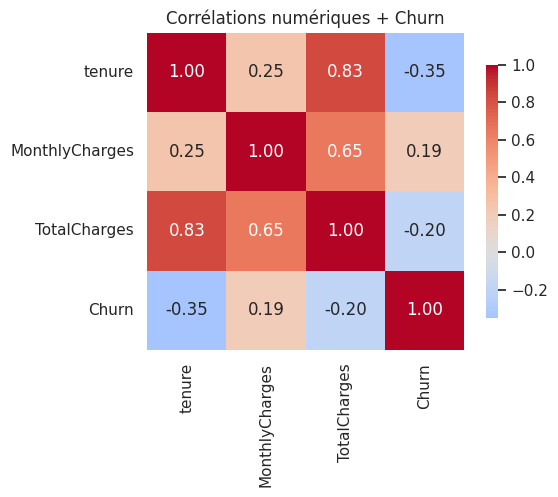


Corrélations avec Churn (tri par valeur absolue) :
tenure            0.352
TotalCharges      0.198
MonthlyCharges    0.193
Name: Churn, dtype: float64


In [39]:
#1. Heatmap de corrélation

df_corr = df[num_cols].copy()
df_corr["Churn"] = (df["Churn"] == "Yes").astype(int)
corr = df_corr.corr()

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title("Corrélations numériques + Churn")
plt.tight_layout()
plt.show()

print("\nCorrélations avec Churn (tri par valeur absolue) :")
print(corr["Churn"].drop("Churn").abs().sort_values(ascending=False).round(3))

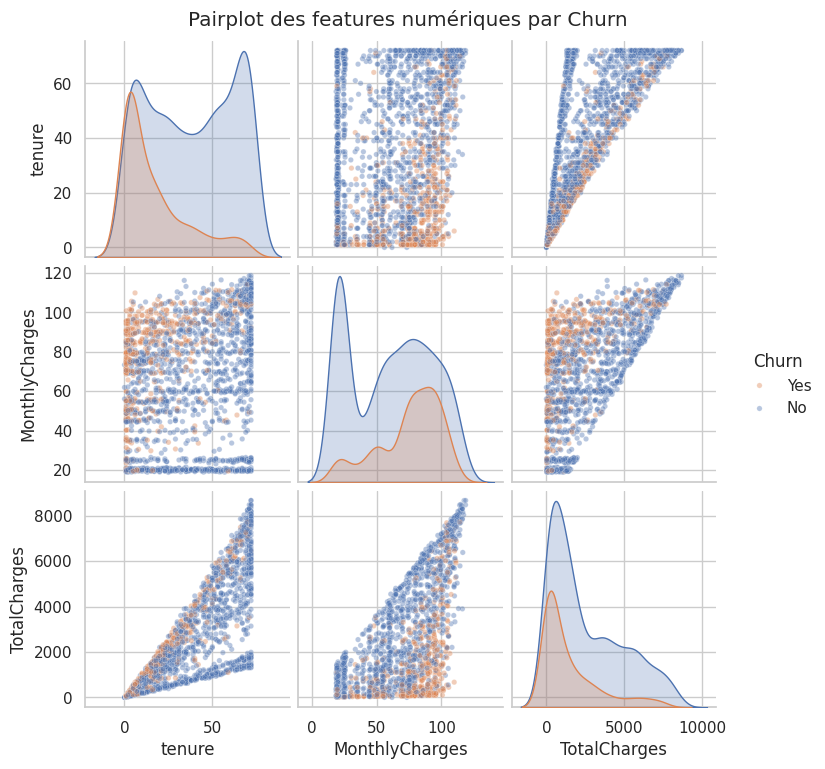

In [40]:
#2. Pairplot ciblé

sample = df[num_cols + ["Churn"]].sample(n=min(2000, len(df)), random_state=RANDOM_STATE)
g = sns.pairplot(sample, hue="Churn", diag_kind="kde",
                 palette={"No": "#4C72B0", "Yes": "#DD8452"},
                 plot_kws={"alpha": 0.4, "s": 15})
g.fig.suptitle("Pairplot des features numériques par Churn", y=1.02)
plt.show()

In [42]:
#3. Multicolinéarité

expected = df["tenure"] * df["MonthlyCharges"]
corr_approx = df["TotalCharges"].corr(expected)
print(f"Corrélation entre TotalCharges et (tenure * MonthlyCharges) : {corr_approx:.4f}")

print("\nCorrélations entre features numériques :")
print(df[num_cols].corr().round(3))

Corrélation entre TotalCharges et (tenure * MonthlyCharges) : 0.9996

Corrélations entre features numériques :
                tenure  MonthlyCharges  TotalCharges
tenure           1.000           0.248         0.826
MonthlyCharges   0.248           1.000         0.651
TotalCharges     0.826           0.651         1.000


In [43]:
#4. Catégorielles cachées

# Lister les colonnes catégorielles à 3 modalités
three_mod_cols = [c for c in cat_cols if df[c].nunique() == 3]
print(f"Colonnes à 3 modalités : {three_mod_cols}\n")

for col in three_mod_cols:
    print(f"--- {col} ---")
    print(df[col].value_counts())
    print()

# Vérifier que "No internet service" == InternetService == "No"
print("=" * 60)
print("Vérification : 'No internet service' équivaut-il à InternetService == 'No' ?")
print("=" * 60)
internet_services = ["OnlineSecurity", "OnlineBackup", "DeviceProtection",
                     "TechSupport", "StreamingTV", "StreamingMovies"]
for col in internet_services:
    sub = df.loc[df["InternetService"] == "No", col].value_counts()
    print(f"{col:20s} si InternetService=='No' -> {dict(sub)}")

# Idem pour MultipleLines vs PhoneService
print("\nIdem pour MultipleLines vs PhoneService :")
print(df.loc[df["PhoneService"] == "No", "MultipleLines"].value_counts().to_dict())

Colonnes à 3 modalités : ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract']

--- MultipleLines ---
MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64

--- InternetService ---
InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64

--- OnlineSecurity ---
OnlineSecurity
No                     3498
Yes                    2019
No internet service    1526
Name: count, dtype: int64

--- OnlineBackup ---
OnlineBackup
No                     3088
Yes                    2429
No internet service    1526
Name: count, dtype: int64

--- DeviceProtection ---
DeviceProtection
No                     3095
Yes                    2422
No internet service    1526
Name: count, dtype: int64

--- TechSupport ---
TechSupport
No                     3473
Yes                    2044
No internet service   